# Earth Limb Day/Night Classification — Geometry & Validation

This notebook demonstrates the corrected geometry used to determine whether the nearest Earth limb point to a target is **sunlit (day)** or **in shadow (night)**. The day/night classification controls which Earth limb keep-out angle is applied (`earthlimb_day_min` vs `earthlimb_night_min`).

## The Bug

The original code projected the target direction onto the observer's horizon plane to find the limb direction $\hat{\ell}$, then checked:

$$\text{sunlit} = \hat{\ell} \cdot \hat{s} > 0$$

This only tests whether the Sun is horizontally aligned with the limb point. But a point on the Earth's surface at the limb has a surface normal with a **large radial (zenith) component** — especially in low Earth orbit where $R_\oplus / d \approx 0.91$.

## The Fix

The surface normal at the nearest limb point is:

$$\hat{n} = \cos(\theta) \, \hat{z} + \sin(\theta) \, \hat{\ell}$$

where $\theta = \arccos(R_\oplus / d)$ is the Earth-limb half-angle. The corrected sunlit check is:

$$\text{sunlit} = \hat{n} \cdot \hat{s} > 0$$

Since $\cos(\theta) \approx 0.91$ and $\sin(\theta) \approx 0.41$, the zenith term **dominates**. The old code ignored this entirely.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from astropy import units as u
from astropy.coordinates import GCRS, SkyCoord, get_body
from astropy.time import Time

from pandoravisibility import Visibility

In [2]:
# TLE
line1 = "1 67395U 80229J   26057.99991898  .00000000  00000-0  37770-3 0    03"
line2 = "2 67395  97.8009  58.3973 0006599 121.8878 132.9207 14.87804761    04"

## 1. Geometry Diagram

The diagram below shows a 2-D cross-section of the geometry in the plane containing the observer, Earth center, and the target direction projected onto the horizon.

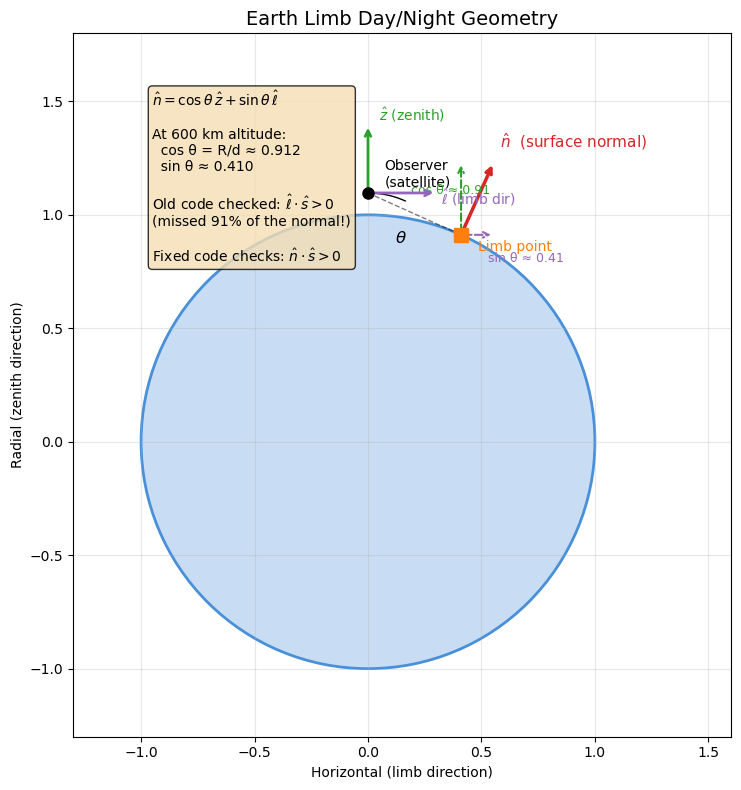

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_aspect("equal")

R = 1.0           # Earth radius (normalised)
d = 1.0 / 0.912   # Observer distance (R/d ~ 0.912 for ~600 km orbit)
theta = np.arccos(R / d)  # limb half-angle

# Earth
earth = plt.Circle((0, 0), R, color="#4a90d9", alpha=0.3, label="Earth")
ax.add_patch(earth)
earth_edge = plt.Circle((0, 0), R, fill=False, color="#4a90d9", lw=2)
ax.add_patch(earth_edge)

# Observer at (0, d) — zenith = +Y
obs = np.array([0, d])
ax.plot(*obs, "ko", ms=8, zorder=5)
ax.annotate("Observer\n(satellite)", obs, textcoords="offset points",
            xytext=(12, 5), fontsize=10)

# Limb point — on Earth's surface at angle theta from zenith
limb_pt = R * np.array([np.sin(theta), np.cos(theta)])
ax.plot(*limb_pt, "s", color="C1", ms=10, zorder=5)
ax.annotate("Limb point", limb_pt, textcoords="offset points",
            xytext=(12, -12), fontsize=10, color="C1")

# Line from observer to limb point (tangent line)
ax.plot([obs[0], limb_pt[0]], [obs[1], limb_pt[1]], "k--", lw=1, alpha=0.5)

# Surface normal at limb point = direction from Earth center to limb point
n_hat = limb_pt / np.linalg.norm(limb_pt)
ax.annotate("", xy=limb_pt + 0.35 * n_hat, xytext=limb_pt,
            arrowprops=dict(arrowstyle="->", color="C3", lw=2.5))
ax.text(*(limb_pt + 0.42 * n_hat), r"$\hat{n}$  (surface normal)",
        fontsize=11, color="C3", ha="left")

# Decompose n_hat into zenith and limb components
z_hat = np.array([0, 1])  # zenith direction
ell_hat = np.array([1, 0])  # horizontal limb direction

# cos(theta) * z_hat component
z_comp = np.cos(theta) * z_hat
ax.annotate("", xy=limb_pt + 0.35 * z_comp / np.linalg.norm(z_comp) * np.cos(theta),
            xytext=limb_pt,
            arrowprops=dict(arrowstyle="->", color="C2", lw=1.5, linestyle="--"))
ax.text(limb_pt[0] - 0.22, limb_pt[1] + 0.18,
        f"cos θ ≈ {np.cos(theta):.2f}", fontsize=9, color="C2")

# sin(theta) * ell_hat component
ell_comp = np.sin(theta) * ell_hat
ax.annotate("", xy=limb_pt + 0.35 * ell_comp / np.linalg.norm(ell_comp) * np.sin(theta),
            xytext=limb_pt,
            arrowprops=dict(arrowstyle="->", color="C4", lw=1.5, linestyle="--"))
ax.text(limb_pt[0] + 0.12, limb_pt[1] - 0.12,
        f"sin θ ≈ {np.sin(theta):.2f}", fontsize=9, color="C4")

# Zenith arrow from observer
ax.annotate("", xy=obs + np.array([0, 0.3]), xytext=obs,
            arrowprops=dict(arrowstyle="->", color="C2", lw=2))
ax.text(obs[0] + 0.05, obs[1] + 0.32, r"$\hat{z}$ (zenith)",
        fontsize=10, color="C2")

# Horizontal limb direction from observer
ax.annotate("", xy=obs + np.array([0.3, 0]), xytext=obs,
            arrowprops=dict(arrowstyle="->", color="C4", lw=2))
ax.text(obs[0] + 0.32, obs[1] - 0.05, r"$\hat{\ell}$ (limb dir)",
        fontsize=10, color="C4")

# Theta arc
arc_angles = np.linspace(0, theta, 50)
arc_r = 0.4
ax.plot(obs[0] + arc_r * np.sin(arc_angles),
        obs[1] - arc_r + arc_r * np.cos(arc_angles),
        "k-", lw=1)
ax.text(obs[0] + 0.12, obs[1] - 0.22, r"$\theta$", fontsize=12)

# Annotation box
textstr = (
    r"$\hat{n} = \cos\theta\,\hat{z} + \sin\theta\,\hat{\ell}$"
    f"\n\nAt 600 km altitude:\n"
    f"  cos θ = R/d ≈ {np.cos(theta):.3f}\n"
    f"  sin θ ≈ {np.sin(theta):.3f}\n\n"
    r"Old code checked: $\hat{\ell} \cdot \hat{s} > 0$"
    "\n(missed 91% of the normal!)\n\n"
    r"Fixed code checks: $\hat{n} \cdot \hat{s} > 0$"
)
props = dict(boxstyle="round", facecolor="wheat", alpha=0.8)
ax.text(-0.95, 1.55, textstr, fontsize=10, verticalalignment="top", bbox=props)

ax.set_xlim(-1.3, 1.6)
ax.set_ylim(-1.3, 1.8)
ax.set_title("Earth Limb Day/Night Geometry", fontsize=14)
ax.set_xlabel("Horizontal (limb direction)")
ax.set_ylabel("Radial (zenith direction)")
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 2. Sunlit Classification — Before vs After Fix

We compare the day/night classification over 7 days for **Capella** (Feb 2026). The old code classified nearly everything as "night"; the fix correctly identifies sunlit limb crossings.

In [4]:
target_coord = SkyCoord(79.17305002, 45.99514569, frame="icrs", unit="deg")
times = Time("2026-02-01T00:00:00") + np.arange(0, 1440 * 7) * u.min

vis = Visibility(line1, line2)
pre = vis._precompute(times)

# Target unit vectors
tgt_gcrs = target_coord.transform_to(GCRS(obstime=times))
tgt_xyz = tgt_gcrs.cartesian.xyz.value
tgt_b = tgt_xyz / np.linalg.norm(tgt_xyz, axis=0, keepdims=True)

zenith = pre["zenith_unit"]
sun_u = pre["body_units"]["sun"]
limb_rad = pre["limb_angle_rad"]

# Old algorithm: no limb_angle_rad (horizontal projection only)
sunlit_old = np.asarray(Visibility._earthlimb_is_sunlit(tgt_b, zenith, sun_u))

# New algorithm: with limb_angle_rad (correct surface normal)
sunlit_new = np.asarray(Visibility._earthlimb_is_sunlit(
    tgt_b, zenith, sun_u, limb_angle_rad=limb_rad
))

print(f"Old algorithm — sunlit: {sunlit_old.sum():5d} / {len(times)} "
      f"({100*sunlit_old.mean():.1f}%)")
print(f"New algorithm — sunlit: {sunlit_new.sum():5d} / {len(times)} "
      f"({100*sunlit_new.mean():.1f}%)")

Old algorithm — sunlit:     0 / 10080 (0.0%)
New algorithm — sunlit:   610 / 10080 (6.1%)


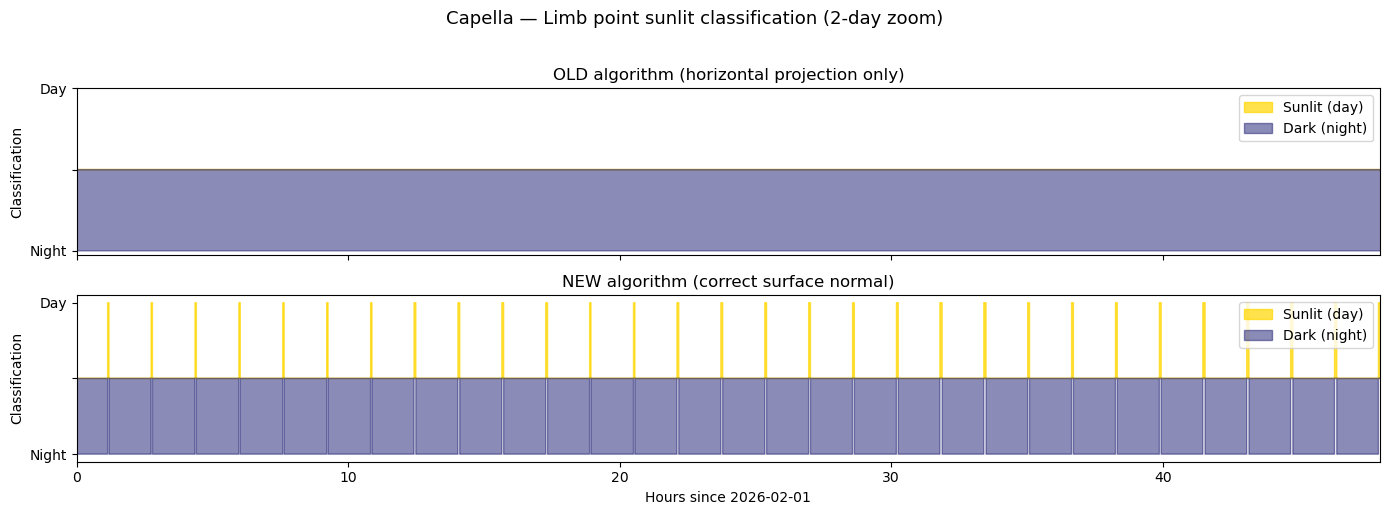

In [5]:
hours = np.arange(len(times)) / 60.0  # minutes → hours

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].fill_between(hours, 0, sunlit_old.astype(int), color="gold",
                     alpha=0.7, label="Sunlit (day)", step="mid")
axes[0].fill_between(hours, 0, (~sunlit_old).astype(int) * -1,
                     color="midnightblue", alpha=0.5, label="Dark (night)", step="mid")
axes[0].set_ylabel("Classification")
axes[0].set_title("OLD algorithm (horizontal projection only)")
axes[0].set_yticks([-1, 0, 1])
axes[0].set_yticklabels(["Night", "", "Day"])
axes[0].legend(loc="upper right")
axes[0].set_xlim(0, 48)  # zoom to 2 days

axes[1].fill_between(hours, 0, sunlit_new.astype(int), color="gold",
                     alpha=0.7, label="Sunlit (day)", step="mid")
axes[1].fill_between(hours, 0, (~sunlit_new).astype(int) * -1,
                     color="midnightblue", alpha=0.5, label="Dark (night)", step="mid")
axes[1].set_ylabel("Classification")
axes[1].set_title("NEW algorithm (correct surface normal)")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["Night", "", "Day"])
axes[1].set_xlabel("Hours since 2026-02-01")
axes[1].legend(loc="upper right")

fig.suptitle("Capella — Limb point sunlit classification (2-day zoom)",
             fontsize=13, y=1.02)
plt.tight_layout()

## 3. Impact on Visibility: `earthlimb_day_min` vs `earthlimb_night_min`

The key test: setting `earthlimb_day_min=355°` should dramatically reduce visibility during sunlit limb crossings. Previously this had **no effect**.

In [6]:
vis_default = Visibility(line1, line2)
vis_day_strict = Visibility(line1, line2,
                            earthlimb_day_min=355 * u.deg,
                            earthlimb_night_min=20 * u.deg)
vis_night_strict = Visibility(line1, line2,
                              earthlimb_day_min=20 * u.deg,
                              earthlimb_night_min=355 * u.deg)

r_default = np.asarray(vis_default.get_visibility(target_coord, times))
r_day_strict = np.asarray(vis_day_strict.get_visibility(target_coord, times))
r_night_strict = np.asarray(vis_night_strict.get_visibility(target_coord, times))

print(f"{'Configuration':<30s} {'Visible':>8s} {'Reduction':>10s}")
print("-" * 50)
print(f"{'Default (limb=20°)':<30s} {r_default.sum():>8d}")
print(f"{'Day=355°, Night=20°':<30s} {r_day_strict.sum():>8d} "
      f"{r_default.sum() - r_day_strict.sum():>+10d}")
print(f"{'Day=20°, Night=355°':<30s} {r_night_strict.sum():>8d} "
      f"{r_default.sum() - r_night_strict.sum():>+10d}")

Configuration                   Visible  Reduction
--------------------------------------------------
Default (limb=20°)                 5319
Day=355°, Night=20°                5177       +142
Day=20°, Night=355°                 142      +5177


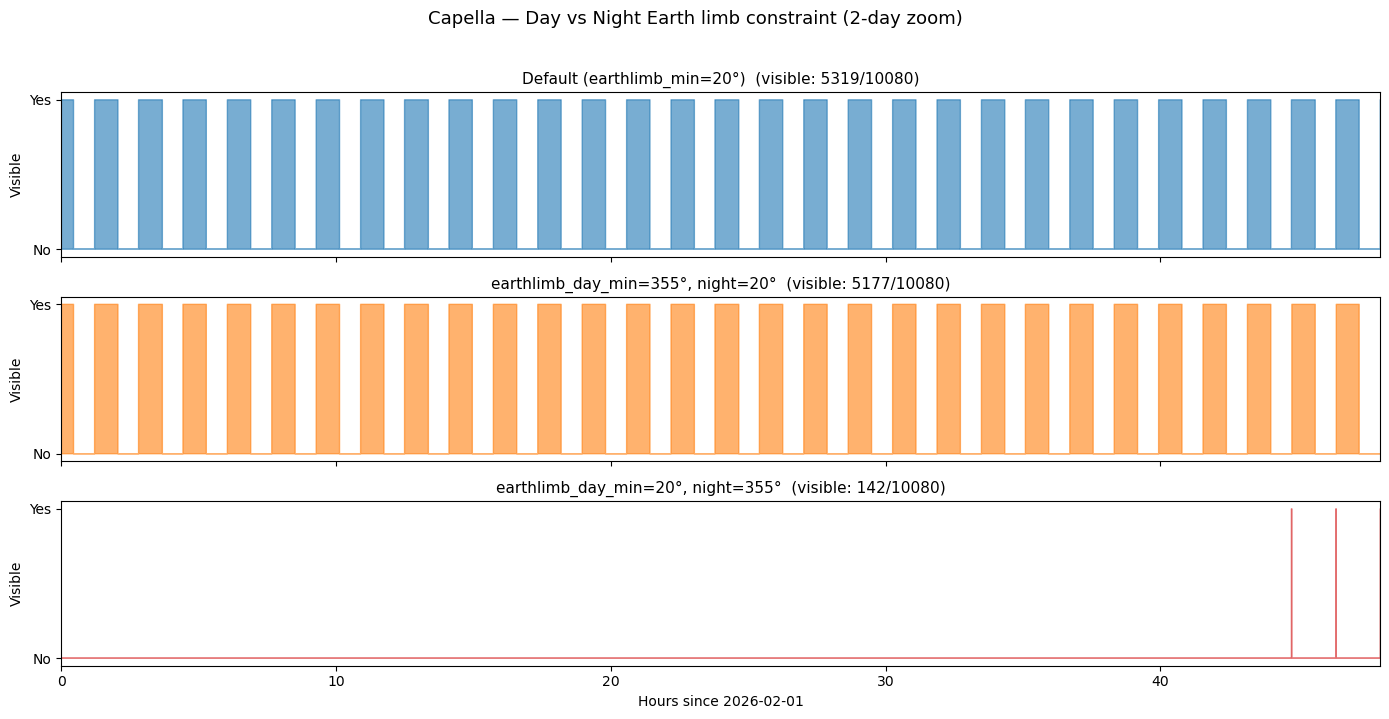

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

for ax, data, title, color in [
    (axes[0], r_default, "Default (earthlimb_min=20°)", "C0"),
    (axes[1], r_day_strict, "earthlimb_day_min=355°, night=20°", "C1"),
    (axes[2], r_night_strict, "earthlimb_day_min=20°, night=355°", "C3"),
]:
    ax.fill_between(hours, 0, data.astype(int), color=color,
                    alpha=0.6, step="mid")
    ax.set_ylabel("Visible")
    ax.set_title(f"{title}  (visible: {data.sum()}/{len(times)})", fontsize=11)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["No", "Yes"])
    ax.set_xlim(0, 48)

axes[2].set_xlabel("Hours since 2026-02-01")
fig.suptitle("Capella — Day vs Night Earth limb constraint (2-day zoom)",
             fontsize=13, y=1.02)
plt.tight_layout()

## 4. Multi-Target Validation (30 days, June 2026)

We test four targets over a full month. For each we compare:
- How many timesteps the old vs new algorithm classifies as "sunlit"
- Whether `earthlimb_day_min` now actually reduces visibility

In [8]:
targets = {
    "Capella":  SkyCoord(79.17305002, 45.99514569, frame="icrs", unit="deg"),
    "GJ 1214":  SkyCoord(258.831, 4.96068, frame="icrs", unit="deg"),
    "WASP-69":  SkyCoord(315.026, -5.09486, frame="icrs", unit="deg"),
    "WASP-107": SkyCoord(188.386, -10.1462, frame="icrs", unit="deg"),
}

times_month = Time("2026-06-01T00:00:00") + np.arange(0, 30 * 144) * (10 * u.min)

vis_def = Visibility(line1, line2)
vis_day = Visibility(line1, line2, earthlimb_day_min=180 * u.deg,
                     earthlimb_night_min=20 * u.deg)
vis_night = Visibility(line1, line2, earthlimb_day_min=20 * u.deg,
                       earthlimb_night_min=180 * u.deg)

pre_month = vis_def._precompute(times_month)
zen_m = pre_month["zenith_unit"]
sun_m = pre_month["body_units"]["sun"]
limb_m = pre_month["limb_angle_rad"]

results = {}
for name, tc in targets.items():
    tgt_gcrs = tc.transform_to(GCRS(obstime=times_month))
    tgt_xyz = tgt_gcrs.cartesian.xyz.value
    tb = tgt_xyz / np.linalg.norm(tgt_xyz, axis=0, keepdims=True)

    old_sunlit = np.asarray(Visibility._earthlimb_is_sunlit(tb, zen_m, sun_m)).sum()
    new_sunlit = np.asarray(Visibility._earthlimb_is_sunlit(
        tb, zen_m, sun_m, limb_angle_rad=limb_m)).sum()

    r_def = np.asarray(vis_def.get_visibility(tc, times_month))
    r_d = np.asarray(vis_day.get_visibility(tc, times_month))
    r_n = np.asarray(vis_night.get_visibility(tc, times_month))

    results[name] = {
        "old_sunlit": old_sunlit, "new_sunlit": new_sunlit,
        "default": r_def.sum(), "day_strict": r_d.sum(), "night_strict": r_n.sum(),
    }

# Print table
print(f"{'Target':<12s} {'Old Sun':>8s} {'New Sun':>8s} {'Default':>8s} "
      f"{'Day=180':>8s} {'Ngt=180':>8s} {'ΔDay':>6s} {'ΔNgt':>6s}")
print("-" * 76)
for name, r in results.items():
    print(f"{name:<12s} {r['old_sunlit']:>8d} {r['new_sunlit']:>8d} "
          f"{r['default']:>8d} {r['day_strict']:>8d} {r['night_strict']:>8d} "
          f"{r['default']-r['day_strict']:>+6d} {r['default']-r['night_strict']:>+6d}")

Target        Old Sun  New Sun  Default  Day=180  Ngt=180   ΔDay   ΔNgt
----------------------------------------------------------------------------
Capella          4320     3283        0        0        0     +0     +0
GJ 1214             0     1059     3150     2499      651   +651  +2499
WASP-69             0     1252     2007     1719      288   +288  +1719
WASP-107          463     1475     1974     1414      560   +560  +1414


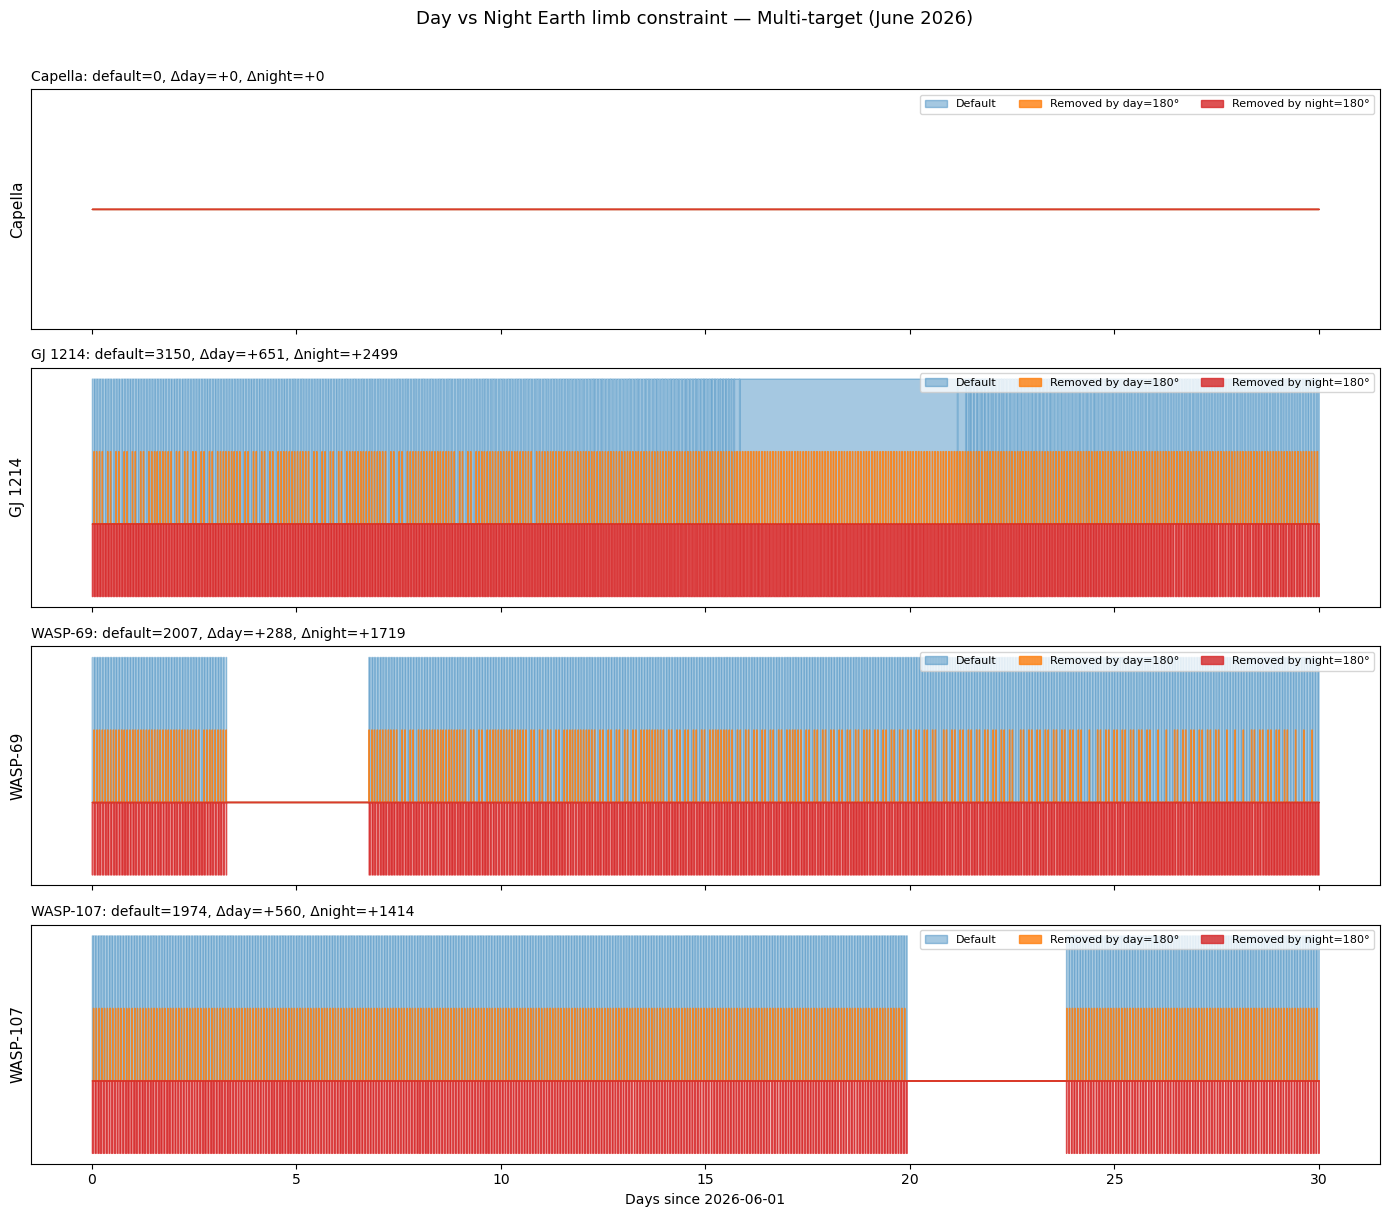

In [9]:
fig, axes = plt.subplots(len(targets), 1, figsize=(14, 3 * len(targets)),
                         sharex=True)

days = np.arange(len(times_month)) / 144.0  # steps → days

for ax, (name, tc) in zip(axes, targets.items()):
    r_def = np.asarray(vis_def.get_visibility(tc, times_month))
    r_d = np.asarray(vis_day.get_visibility(tc, times_month))
    r_n = np.asarray(vis_night.get_visibility(tc, times_month))

    ax.fill_between(days, 0, r_def.astype(float), color="C0",
                    alpha=0.4, step="mid", label="Default")
    # Show what the day constraint removes (visible in default but not in day_strict)
    lost_day = r_def & ~r_d
    ax.fill_between(days, 0, lost_day.astype(float) * 0.5, color="C1",
                    alpha=0.8, step="mid", label="Removed by day=180°")
    # Show what the night constraint removes
    lost_night = r_def & ~r_n
    ax.fill_between(days, 0, -lost_night.astype(float) * 0.5, color="C3",
                    alpha=0.8, step="mid", label="Removed by night=180°")

    r = results[name]
    ax.set_ylabel(name, fontsize=11)
    ax.set_yticks([])
    ax.legend(loc="upper right", fontsize=8, ncol=3)
    ax.set_title(f"{name}: default={r['default']}, "
                f"Δday={r['default']-r['day_strict']:+d}, "
                f"Δnight={r['default']-r['night_strict']:+d}",
                fontsize=10, loc="left")

axes[-1].set_xlabel("Days since 2026-06-01")
fig.suptitle("Day vs Night Earth limb constraint — Multi-target (June 2026)",
             fontsize=13, y=1.01)
plt.tight_layout()

## 5. Sunlit Fraction vs Orbital Phase

For one target we plot the sunlit classification alongside the satellite's day/night status (whether the satellite itself is in sunlight or shadow). This highlights that the *limb point* sunlit status is related to, but distinct from, the satellite's own illumination.

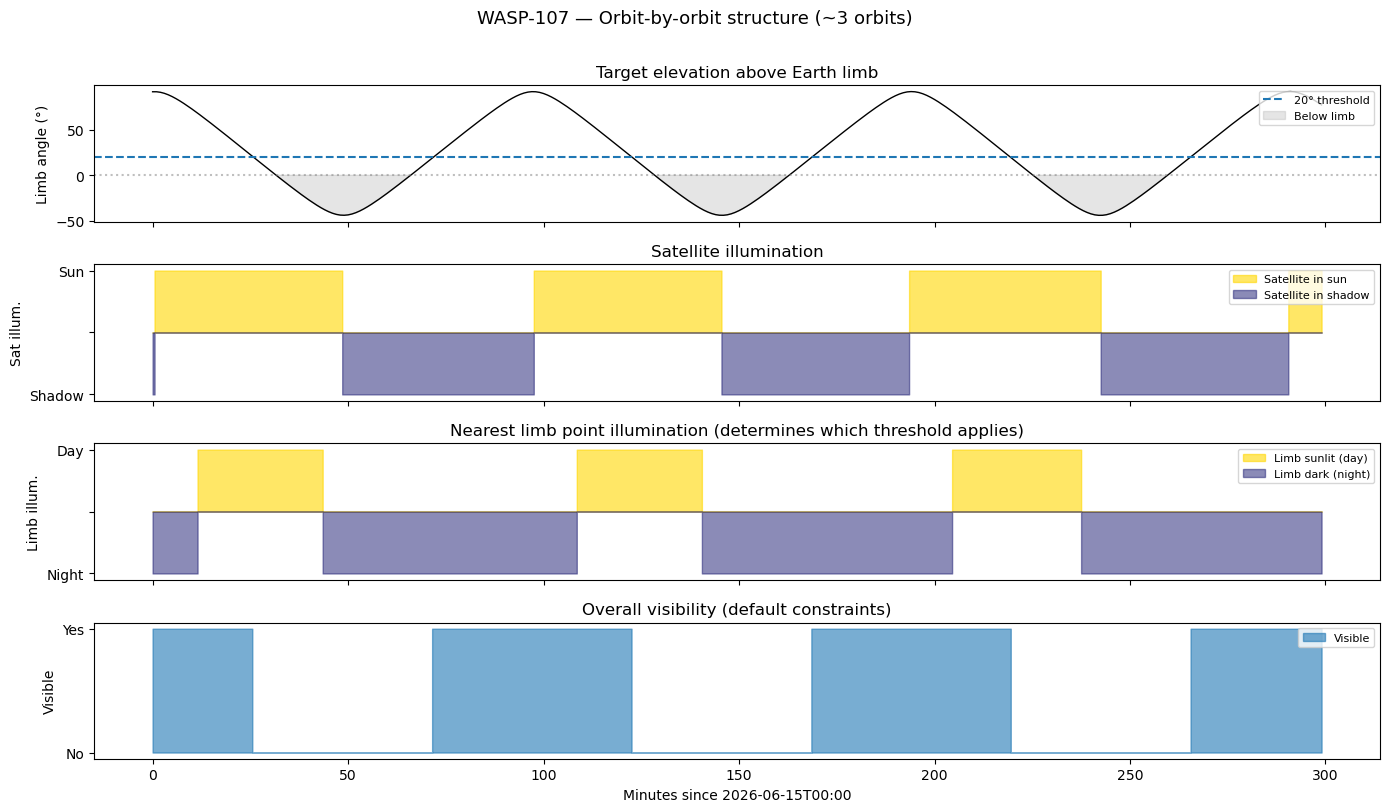

In [10]:
# Use WASP-107 over 3 orbits (~5 hours)
tc = targets["WASP-107"]
t_short = Time("2026-06-15T00:00:00") + np.arange(0, 300) * u.min

vis_check = Visibility(line1, line2)
pre_s = vis_check._precompute(t_short)

tgt_gcrs = tc.transform_to(GCRS(obstime=t_short))
tgt_xyz = tgt_gcrs.cartesian.xyz.value
tb = tgt_xyz / np.linalg.norm(tgt_xyz, axis=0, keepdims=True)

zen_s = pre_s["zenith_unit"]
sun_s = pre_s["body_units"]["sun"]
limb_s = pre_s["limb_angle_rad"]

# Sunlit classification (new)
sunlit_fix = np.asarray(Visibility._earthlimb_is_sunlit(
    tb, zen_s, sun_s, limb_angle_rad=limb_s))

# Satellite in sunlight: dot(zenith, sun) > 0 roughly
dot_zen_sun = np.sum(zen_s * sun_s, axis=0)

# Limb angle (target elevation above limb)
limb_deg = vis_check._fast_limb_deg(tb, zen_s, limb_s)

# Visibility
vis_result = np.asarray(vis_check.get_visibility(tc, t_short))

minutes = np.arange(len(t_short))

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

# 1. Target above/below Earth limb
axes[0].plot(minutes, limb_deg, "k-", lw=1)
axes[0].axhline(20, color="C0", ls="--", label="20° threshold")
axes[0].axhline(0, color="gray", ls=":", alpha=0.5)
axes[0].fill_between(minutes, limb_deg, 0,
                     where=limb_deg < 0, color="gray", alpha=0.2, label="Below limb")
axes[0].set_ylabel("Limb angle (°)")
axes[0].set_title("Target elevation above Earth limb")
axes[0].legend(loc="upper right", fontsize=8)

# 2. Satellite day/night (dot zenith·sun)
axes[1].fill_between(minutes, 0, (dot_zen_sun > 0).astype(int),
                     color="gold", alpha=0.6, step="mid", label="Satellite in sun")
axes[1].fill_between(minutes, 0, -(dot_zen_sun <= 0).astype(int),
                     color="midnightblue", alpha=0.5, step="mid",
                     label="Satellite in shadow")
axes[1].set_ylabel("Sat illum.")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["Shadow", "", "Sun"])
axes[1].set_title("Satellite illumination")
axes[1].legend(loc="upper right", fontsize=8)

# 3. Limb point sunlit/dark
axes[2].fill_between(minutes, 0, sunlit_fix.astype(int),
                     color="gold", alpha=0.6, step="mid", label="Limb sunlit (day)")
axes[2].fill_between(minutes, 0, -(~sunlit_fix).astype(int),
                     color="midnightblue", alpha=0.5, step="mid",
                     label="Limb dark (night)")
axes[2].set_ylabel("Limb illum.")
axes[2].set_yticks([-1, 0, 1])
axes[2].set_yticklabels(["Night", "", "Day"])
axes[2].set_title("Nearest limb point illumination (determines which threshold applies)")
axes[2].legend(loc="upper right", fontsize=8)

# 4. Overall visibility
axes[3].fill_between(minutes, 0, vis_result.astype(int),
                     color="C0", alpha=0.6, step="mid", label="Visible")
axes[3].set_ylabel("Visible")
axes[3].set_yticks([0, 1])
axes[3].set_yticklabels(["No", "Yes"])
axes[3].set_xlabel("Minutes since 2026-06-15T00:00")
axes[3].set_title("Overall visibility (default constraints)")
axes[3].legend(loc="upper right", fontsize=8)

fig.suptitle("WASP-107 — Orbit-by-orbit structure (~3 orbits)",
             fontsize=13, y=1.01)
plt.tight_layout()

## 6. Effective Threshold Map

When `earthlimb_day_min=30°` and `earthlimb_night_min=10°`, the effective threshold changes per timestep. This plot shows which threshold is active at each moment.

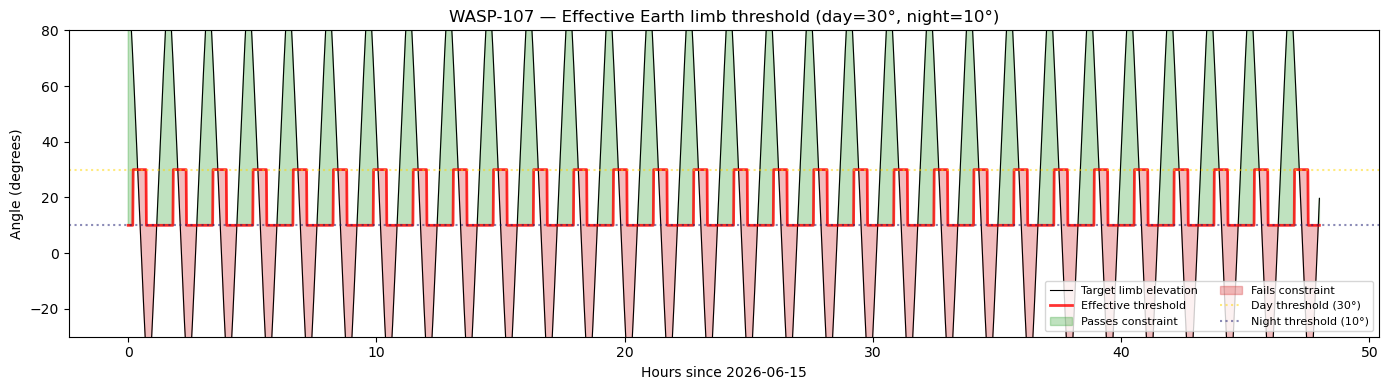

In [11]:
vis_daynight = Visibility(line1, line2,
                          earthlimb_day_min=30 * u.deg,
                          earthlimb_night_min=10 * u.deg)

# Compute effective threshold for WASP-107 over 2 days
tc = targets["WASP-107"]
t_2d = Time("2026-06-15T00:00:00") + np.arange(0, 2 * 1440) * u.min
pre_2d = vis_daynight._precompute(t_2d)

tgt_gcrs = tc.transform_to(GCRS(obstime=t_2d))
tgt_xyz = tgt_gcrs.cartesian.xyz.value
tb = tgt_xyz / np.linalg.norm(tgt_xyz, axis=0, keepdims=True)

eff_threshold = vis_daynight._effective_earthlimb_min_deg(
    tb, pre_2d["zenith_unit"], pre_2d["body_units"]["sun"],
    limb_angle_rad=pre_2d["limb_angle_rad"]
)
limb_elev = vis_daynight._fast_limb_deg(
    tb, pre_2d["zenith_unit"], pre_2d["limb_angle_rad"]
)

hrs = np.arange(len(t_2d)) / 60.0

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hrs, limb_elev, "k-", lw=0.8, label="Target limb elevation")
ax.plot(hrs, eff_threshold, "r-", lw=2, label="Effective threshold", alpha=0.8)
ax.fill_between(hrs, eff_threshold, limb_elev,
                where=limb_elev >= eff_threshold,
                color="C2", alpha=0.3, label="Passes constraint")
ax.fill_between(hrs, eff_threshold, limb_elev,
                where=limb_elev < eff_threshold,
                color="C3", alpha=0.3, label="Fails constraint")
ax.axhline(30, color="gold", ls=":", alpha=0.5, label="Day threshold (30°)")
ax.axhline(10, color="midnightblue", ls=":", alpha=0.5, label="Night threshold (10°)")
ax.set_xlabel("Hours since 2026-06-15")
ax.set_ylabel("Angle (degrees)")
ax.set_title("WASP-107 — Effective Earth limb threshold (day=30°, night=10°)",
             fontsize=12)
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.set_ylim(-30, 80)
plt.tight_layout()

## Summary

The fix to `_earthlimb_is_sunlit` correctly accounts for the full surface normal at the nearest Earth limb point, including the dominant radial (zenith) component. This makes `earthlimb_day_min` functional — setting it to extreme values now meaningfully changes the visibility calculation, as demonstrated across multiple targets and time periods.